In [1]:
%pip install -q "gymnasium[atari]==1.2.0" "ale-py==0.11.2"

import random
import collections
import gc
import time
import re
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 2
gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, flush=True)


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class FireResetEnv(gym.Wrapper):
    """Preme FIRE all'avvio dell'episodio."""

    def reset(self, **kwargs):
        observation, info = self.env.reset(**kwargs)
        observation, _, terminated, truncated, info = self.env.step(1)
        if terminated or truncated:
            observation, info = self.env.reset(**kwargs)
        return observation, info


class PongThreeActions(gym.ActionWrapper):
    """Espone soltanto NOOP (0), UP/RIGHT (2), DOWN/LEFT (3)."""

    def __init__(self, env):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)

    def action(self, action):
        return self.action_mapping[int(action)]

Note: you may need to restart the kernel to use updated packages.
Dispositivo: cuda


In [2]:
class PongBallContactDetector:
    """Rileva il rimbalzo sulla racchetta destra da uno stack di frame."""

    def __init__(
        self,
        play_y=(8, 80),
        ball_x=(10, 72),
        player_x=(72, 82),
        contrast_threshold=35,
        motion_threshold=10,
        max_ball_pixels=40,
        min_horizontal_speed=0.5,
        min_contact_x=60.0,
        max_vertical_gap=14.0,
    ):
        self.play_y = tuple(play_y)
        self.ball_x = tuple(ball_x)
        self.player_x = tuple(player_x)
        self.contrast_threshold = float(contrast_threshold)
        self.motion_threshold = float(motion_threshold)
        self.max_ball_pixels = int(max_ball_pixels)
        self.min_horizontal_speed = float(min_horizontal_speed)
        self.min_contact_x = float(min_contact_x)
        self.max_vertical_gap = float(max_vertical_gap)

    def _background(self, frame):
        y0, y1 = self.play_y
        x0, x1 = self.ball_x
        return float(np.median(frame[y0:y1, x0:x1]))

    def _locate_current_ball(self, previous, current):
        previous = previous.astype(np.int16, copy=False)
        current = current.astype(np.int16, copy=False)
        y0, y1 = self.play_y
        x0, x1 = self.ball_x
        background = self._background(current)

        current_roi = current[y0:y1, x0:x1]
        previous_roi = previous[y0:y1, x0:x1]
        object_mask = (
            np.abs(current_roi - background) >= self.contrast_threshold
        )
        moving_mask = (
            np.abs(current_roi - previous_roi) >= self.motion_threshold
        )
        y_local, x_local = np.nonzero(object_mask & moving_mask)

        if not 1 <= y_local.size <= self.max_ball_pixels:
            return None
        return {
            "x": float(np.median(x_local + x0)),
            "y": float(np.median(y_local + y0)),
        }

    def _locate_player_paddle(self, frame):
        frame = frame.astype(np.int16, copy=False)
        y0, y1 = self.play_y
        x0, x1 = self.player_x
        background = self._background(frame)
        roi = frame[y0:y1, x0:x1]
        y_local, _ = np.nonzero(
            np.abs(roi - background) >= self.contrast_threshold
        )
        if y_local.size < 2:
            return None
        return float(np.median(y_local + y0))

    def analyze(self, observation):
        frames = np.asarray(observation)
        if frames.ndim != 3 or frames.shape[0] < 4:
            raise ValueError("Il rilevatore richiede uno stack di almeno 4 frame")

        frames = frames[-4:]
        positions = [
            self._locate_current_ball(frames[i - 1], frames[i])
            for i in range(1, 4)
        ]
        paddle_y = self._locate_player_paddle(frames[-1])

        details = {
            "contact": False,
            "positions": positions,
            "paddle_y": paddle_y,
            "dx_before": None,
            "dx_after": None,
            "turning_x": None,
            "turning_y": None,
        }
        if paddle_y is None or any(position is None for position in positions):
            return details

        dx_before = positions[1]["x"] - positions[0]["x"]
        dx_after = positions[2]["x"] - positions[1]["x"]
        turning_x = positions[1]["x"]
        turning_y = positions[1]["y"]

        moving_toward_player = dx_before >= self.min_horizontal_speed
        moving_away_after = dx_after <= -self.min_horizontal_speed
        near_player_side = turning_x >= self.min_contact_x
        vertically_compatible = (
            abs(turning_y - paddle_y) <= self.max_vertical_gap
        )

        details.update(
            {
                "contact": bool(
                    moving_toward_player
                    and moving_away_after
                    and near_player_side
                    and vertically_compatible
                ),
                "dx_before": dx_before,
                "dx_after": dx_after,
                "turning_x": turning_x,
                "turning_y": turning_y,
            }
        )
        return details

    def __call__(self, observation):
        return self.analyze(observation)["contact"]


class BallContactRewardShaping(gym.Wrapper):
    """Aggiunge un bonus una sola volta per ogni contatto rilevato."""

    def __init__(self, env, contact_bonus, detector, cooldown_steps=3):
        super().__init__(env)
        if contact_bonus < 0.0:
            raise ValueError("contact_bonus deve essere non negativo")
        if cooldown_steps < 0:
            raise ValueError("cooldown_steps deve essere non negativo")
        self.contact_bonus = float(contact_bonus)
        self.detector = detector
        self.cooldown_steps = int(cooldown_steps)
        self.cooldown = 0

    def reset(self, **kwargs):
        self.cooldown = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        observation, raw_reward, terminated, truncated, info = self.env.step(action)
        raw_reward = float(raw_reward)
        candidate_contact = bool(self.detector(observation))

        if self.cooldown > 0:
            self.cooldown -= 1

        ball_contact = candidate_contact and self.cooldown == 0
        bonus = self.contact_bonus if ball_contact else 0.0
        if ball_contact:
            self.cooldown = self.cooldown_steps

        shaped_reward = raw_reward + bonus
        info = dict(info)
        info["raw_reward"] = raw_reward
        info["ball_contact"] = ball_contact
        info["candidate_contact"] = candidate_contact
        info["contact_bonus"] = bonus
        return observation, shaped_reward, terminated, truncated, info

In [3]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        self.buffer.append(
            (
                np.array(state, dtype=np.uint8),
                action,
                reward,
                np.array(next_state, dtype=np.uint8),
                terminated,
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, terminated = zip(*batch)
        return (
            torch.tensor(np.array(state), dtype=torch.uint8, device=device).float(),
            torch.tensor(action, dtype=torch.int64, device=device),
            torch.tensor(reward, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_state), dtype=torch.uint8, device=device).float(),
            torch.tensor(terminated, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=20, base_seed=1000):
    """Valuta esclusivamente sul reward Atari originale."""
    scores = []
    for episode in range(episodes):
        state, _ = eval_env.reset(seed=base_seed + episode)
        if model is None:
            eval_env.action_space.seed(base_seed + episode)

        done = False
        total_reward = 0.0
        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.tensor(
                    np.array(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.no_grad():
                    action = model(state_t).argmax(dim=1).item()
            state, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward
        scores.append(total_reward)

    return float(np.mean(scores)), float(np.std(scores))

In [4]:
BUFFER_CAPACITY = 100000
TOTAL_STEPS = 1800000
LEARNING_STARTS = 20000
TRAIN_FREQ = 4
EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800000
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2000
CHECKPOINTS = [600000, 900000, 1200000, 1500000, 1800000]
EVAL_EPISODES = 20
HUMAN_BENCHMARK = 9.3

SMALL_CONTACT_BONUS = 0.02
MODERATE_CONTACT_BONUS = 0.10
AGGRESSIVE_CONTACT_BONUS = 0.50

CONTACT_DETECTOR_KWARGS = {
    "play_y": (8, 80),
    "ball_x": (10, 72),
    "player_x": (72, 82),
    "contrast_threshold": 35,
    "motion_threshold": 10,
    "max_ball_pixels": 40,
    "min_horizontal_speed": 0.5,
    "min_contact_x": 60.0,
    "max_vertical_gap": 14.0,
}
CONTACT_COOLDOWN_STEPS = 3

assert TOTAL_STEPS in CHECKPOINTS
assert 0 < SMALL_CONTACT_BONUS < MODERATE_CONTACT_BONUS < AGGRESSIVE_CONTACT_BONUS


def make_env(contact_bonus=0.0):
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env)
    env = FrameStackObservation(env, stack_size=4)


    if contact_bonus > 0.0:
        env = BallContactRewardShaping(
            env,
            contact_bonus=contact_bonus,
            detector=PongBallContactDetector(**CONTACT_DETECTOR_KWARGS),
            cooldown_steps=CONTACT_COOLDOWN_STEPS,
        )

    return env

In [5]:
def inspect_contact_detector(n_samples=4, max_steps=3000, seed=SEED):
    detector = PongBallContactDetector(**CONTACT_DETECTOR_KWARGS)
    diagnostic_env = make_env(contact_bonus=0.0)
    diagnostic_env.action_space.seed(seed)
    state, _ = diagnostic_env.reset(seed=seed)

    samples = []
    candidate_count = 0
    for _ in range(max_steps):
        action = diagnostic_env.action_space.sample()
        state, _, terminated, truncated, _ = diagnostic_env.step(action)
        details = detector.analyze(state)
        if details["contact"]:
            candidate_count += 1
            if len(samples) < n_samples:
                samples.append((np.asarray(state)[-1].copy(), details))
        if terminated or truncated:
            state, _ = diagnostic_env.reset()

    diagnostic_env.close()
    print(f"Contatti candidati: {candidate_count} in {max_steps} passi.")

    if not samples:
        print(
            "Nessun contatto visualizzabile: aumentare max_steps oppure "
            "correggere regioni e soglie."
        )
        return

    fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
    axes = np.atleast_1d(axes)
    for axis, (frame, details) in zip(axes, samples):
        axis.imshow(frame, cmap="gray", vmin=0, vmax=255)
        for index, position in enumerate(details["positions"]):
            axis.scatter(
                position["x"],
                position["y"],
                c="red",
                s=35 + 15 * index,
                marker="x",
            )
        axis.axhline(details["paddle_y"], color="cyan", linewidth=1.5)
        axis.set_title(
            f"dx: {details['dx_before']:.1f} -> {details['dx_after']:.1f}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()


inspect_contact_detector()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Contatti candidati: 0 in 3000 passi.
Nessun contatto visualizzabile: aumentare max_steps oppure correggere regioni e soglie.


In [6]:
def train_contact_experiment(label, contact_bonus, seed=SEED):
    set_all_seeds(seed)
    train_env = make_env(contact_bonus=contact_bonus)
    eval_env = make_env(contact_bonus=0.0)
    train_env.action_space.seed(seed)
    eval_env.action_space.seed(seed + 1)

    n_actions = train_env.action_space.n
    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    replay_buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, _ = train_env.reset(seed=seed)
    raw_ep_return = 0.0
    shaped_ep_return = 0.0
    contact_bonus_total = 0.0
    contact_count = 0
    rally_steps = 0
    completed_rally_lengths = []

    history = {
        "step": [],
        "raw_return": [],
        "shaped_return": [],
        "contact_bonus": [],
        "contact_count": [],
        "mean_rally": [],
        "loss": [],
    }
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()
    print(f"\n=== {label}: +{contact_bonus:.2f} per contatto ===", flush=True)

    for step in range(1, TOTAL_STEPS + 1):
        epsilon = max(
            EPS_END,
            EPS_START - (EPS_START - EPS_END) * (step / DECAY_STEPS),
        )

        if random.random() < epsilon:
            action = train_env.action_space.sample()
        else:
            state_t = torch.tensor(
                np.array(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.no_grad():
                action = policy_net(state_t).argmax(dim=1).item()

        next_state, shaped_reward, terminated, truncated, info = train_env.step(action)
        raw_reward = info["raw_reward"]
        bonus = info["contact_bonus"]
        contact = info["ball_contact"]

        replay_buffer.push(
            state,
            action,
            shaped_reward,
            next_state,
            terminated,
        )
        state = next_state
        raw_ep_return += raw_reward
        shaped_ep_return += shaped_reward
        contact_bonus_total += bonus
        contact_count += int(contact)
        rally_steps += 1

        if raw_reward != 0.0:
            completed_rally_lengths.append(rally_steps)
            rally_steps = 0

        if terminated or truncated:
            history["step"].append(step)
            history["raw_return"].append(raw_ep_return)
            history["shaped_return"].append(shaped_ep_return)
            history["contact_bonus"].append(contact_bonus_total)
            history["contact_count"].append(contact_count)
            history["mean_rally"].append(
                float(np.mean(completed_rally_lengths))
                if completed_rally_lengths
                else 0.0
            )

            if len(history["raw_return"]) % 20 == 0:
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"{label} | step {step:7d}/{TOTAL_STEPS} | "
                    f"ep {len(history['raw_return']):4d} | "
                    f"raw20 {np.mean(history['raw_return'][-20:]):6.2f} | "
                    f"shaped20 {np.mean(history['shaped_return'][-20:]):6.2f} | "
                    f"contatti20 {np.mean(history['contact_count'][-20:]):5.1f} | "
                    f"rally20 {np.mean(history['mean_rally'][-20:]):6.1f} | "
                    f"eps {epsilon:.3f} | {elapsed:.1f}m",
                    flush=True,
                )

            state, _ = train_env.reset()
            raw_ep_return = 0.0
            shaped_ep_return = 0.0
            contact_bonus_total = 0.0
            contact_count = 0
            rally_steps = 0
            completed_rally_lengths = []

        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_terminated = replay_buffer.sample(BATCH_SIZE)

            with torch.no_grad():
                max_next_q = target_net(b_ns).max(dim=1).values
                target_q = b_r + (1.0 - b_terminated) * GAMMA * max_next_q

            current_q = policy_net(b_s).gather(1, b_a.unsqueeze(1)).squeeze(1)
            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()
            history["loss"].append(loss.item())

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            policy_net.eval()
            mean_score, std_score = evaluate(
                eval_env,
                model=policy_net,
                episodes=EVAL_EPISODES,
            )
            policy_net.train()
            checkpoint_results[step] = (mean_score, std_score)
            print(
                f"--- {label} @ {step}: Atari raw "
                f"{mean_score:.2f} +/- {std_score:.2f} ---",
                flush=True,
            )

            safe_label = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
            torch.save(
                {
                    "step": step,
                    "label": label,
                    "contact_bonus": contact_bonus,
                    "detector_kwargs": CONTACT_DETECTOR_KWARGS,
                    "policy_state_dict": policy_net.state_dict(),
                    "target_state_dict": target_net.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                },
                f"dqn_pong_{safe_label}_{step}.pth",
            )

    train_env.close()
    eval_env.close()

    result = {
        "label": label,
        "contact_bonus": contact_bonus,
        "checkpoints": checkpoint_results,
        "history": history,
    }

    del replay_buffer, policy_net, target_net, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

In [7]:
small_run = train_contact_experiment(
    label="Contatto piccolo",
    contact_bonus=SMALL_CONTACT_BONUS,
)


=== Contatto piccolo: +0.02 per contatto ===
Contatto piccolo | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -20.60 | contatti20   0.0 | rally20   45.5 | eps 0.976 | 0.6m
Contatto piccolo | step   39876/1800000 | ep   40 | raw20 -20.55 | shaped20 -20.55 | contatti20   0.0 | rally20   47.4 | eps 0.951 | 1.8m
Contatto piccolo | step   59246/1800000 | ep   60 | raw20 -20.40 | shaped20 -20.40 | contatti20   0.1 | rally20   44.7 | eps 0.927 | 2.9m
Contatto piccolo | step   78941/1800000 | ep   80 | raw20 -20.55 | shaped20 -20.55 | contatti20   0.0 | rally20   45.8 | eps 0.902 | 4.1m
Contatto piccolo | step   98955/1800000 | ep  100 | raw20 -20.35 | shaped20 -20.35 | contatti20   0.0 | rally20   46.1 | eps 0.878 | 5.3m
Contatto piccolo | step  118979/1800000 | ep  120 | raw20 -20.60 | shaped20 -20.60 | contatti20   0.0 | rally20   46.7 | eps 0.853 | 6.5m
Contatto piccolo | step  139031/1800000 | ep  140 | raw20 -20.35 | shaped20 -20.35 | contatti20   0.0 | rally20   46.2 | eps 0

In [8]:
moderate_run = train_contact_experiment(
    label="Contatto moderato",
    contact_bonus=MODERATE_CONTACT_BONUS,
)


=== Contatto moderato: +0.10 per contatto ===
Contatto moderato | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -20.60 | contatti20   0.0 | rally20   45.5 | eps 0.976 | 0.5m
Contatto moderato | step   39347/1800000 | ep   40 | raw20 -20.60 | shaped20 -20.60 | contatti20   0.0 | rally20   46.2 | eps 0.951 | 1.7m
Contatto moderato | step   59461/1800000 | ep   60 | raw20 -20.20 | shaped20 -20.20 | contatti20   0.0 | rally20   46.0 | eps 0.926 | 2.8m
Contatto moderato | step   79873/1800000 | ep   80 | raw20 -20.20 | shaped20 -20.20 | contatti20   0.0 | rally20   46.8 | eps 0.901 | 4.0m
Contatto moderato | step  100939/1800000 | ep  100 | raw20 -20.30 | shaped20 -20.30 | contatti20   0.0 | rally20   48.4 | eps 0.875 | 5.3m
Contatto moderato | step  121300/1800000 | ep  120 | raw20 -20.50 | shaped20 -20.49 | contatti20   0.1 | rally20   47.2 | eps 0.850 | 6.5m
Contatto moderato | step  144410/1800000 | ep  140 | raw20 -19.95 | shaped20 -19.95 | contatti20   0.0 | rally20   52.3

In [9]:
aggressive_run = train_contact_experiment(
    label="Contatto aggressivo",
    contact_bonus=AGGRESSIVE_CONTACT_BONUS,
)


=== Contatto aggressivo: +0.50 per contatto ===
Contatto aggressivo | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -20.60 | contatti20   0.0 | rally20   45.5 | eps 0.976 | 0.5m
Contatto aggressivo | step   39305/1800000 | ep   40 | raw20 -20.50 | shaped20 -20.50 | contatti20   0.0 | rally20   45.9 | eps 0.951 | 1.7m
Contatto aggressivo | step   58519/1800000 | ep   60 | raw20 -20.45 | shaped20 -20.45 | contatti20   0.0 | rally20   44.5 | eps 0.928 | 2.7m
Contatto aggressivo | step   78751/1800000 | ep   80 | raw20 -20.30 | shaped20 -20.30 | contatti20   0.0 | rally20   46.5 | eps 0.903 | 3.9m
Contatto aggressivo | step   98247/1800000 | ep  100 | raw20 -20.55 | shaped20 -20.55 | contatti20   0.0 | rally20   45.4 | eps 0.878 | 5.1m
Contatto aggressivo | step  117330/1800000 | ep  120 | raw20 -20.75 | shaped20 -20.75 | contatti20   0.0 | rally20   44.9 | eps 0.855 | 6.2m
Contatto aggressivo | step  136387/1800000 | ep  140 | raw20 -20.65 | shaped20 -20.65 | contatti20   0.0 

In [10]:
def tail_mean(run, key, n=100):
    values = run["history"][key]
    return float(np.mean(values[-n:])) if values else float("nan")

RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]
print("CONFRONTO SUL REWARD ATARI ORIGINALE (media +/- std su 20 episodi)")
print(" step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo")
for checkpoint in CHECKPOINTS:
    means = [run["checkpoints"][checkpoint][0] for _, run in RUNS]
    scores = [f"{run['checkpoints'][checkpoint][0]:6.2f} +/- {run['checkpoints'][checkpoint][1]:5.2f}" for _, run in RUNS]
    print(f"{checkpoint // 1000:4d}k | " + " | ".join(scores)
          + f" | {means[1]-means[0]:+6.2f} | {means[2]-means[0]:+6.2f}")
print("\nDIAGNOSTICA ULTIMI 100 EPISODI DI TRAINING")
for _, run in RUNS:
    print(f"{run['label']}: raw={tail_mean(run, 'raw_return'):.2f}, "
          f"shaped={tail_mean(run, 'shaped_return'):.2f}, "
          f"contatti={tail_mean(run, 'contact_count'):.2f}, "
          f"rally medio={tail_mean(run, 'mean_rally'):.1f}")

CONFRONTO SUL REWARD ATARI ORIGINALE (media +/- std su 20 episodi)
 step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo
 600k |  -9.55 +/-  4.03 | -11.15 +/-  3.42 | -21.00 +/-  0.00 |  -1.60 | -11.45
 900k |  -3.25 +/-  5.74 |  -5.60 +/-  4.09 | -21.00 +/-  0.00 |  -2.35 | -17.75
1200k |   0.25 +/-  5.80 |   7.10 +/-  4.76 | -21.00 +/-  0.00 |  +6.85 | -21.25
1500k |  14.55 +/-  3.26 |   8.15 +/-  4.73 | -21.00 +/-  0.00 |  -6.40 | -35.55
1800k |  13.95 +/-  5.38 |  15.15 +/-  2.74 | -21.00 +/-  0.00 |  +1.20 | -34.95

DIAGNOSTICA ULTIMI 100 EPISODI DI TRAINING
Contatto piccolo: raw=11.99, shaped=11.99, contatti=0.21, rally medio=166.9
Contatto moderato: raw=8.82, shaped=8.89, contatti=0.71, rally medio=191.8
Contatto aggressivo: raw=-21.00, shaped=-21.00, contatti=0.00, rally medio=37.6


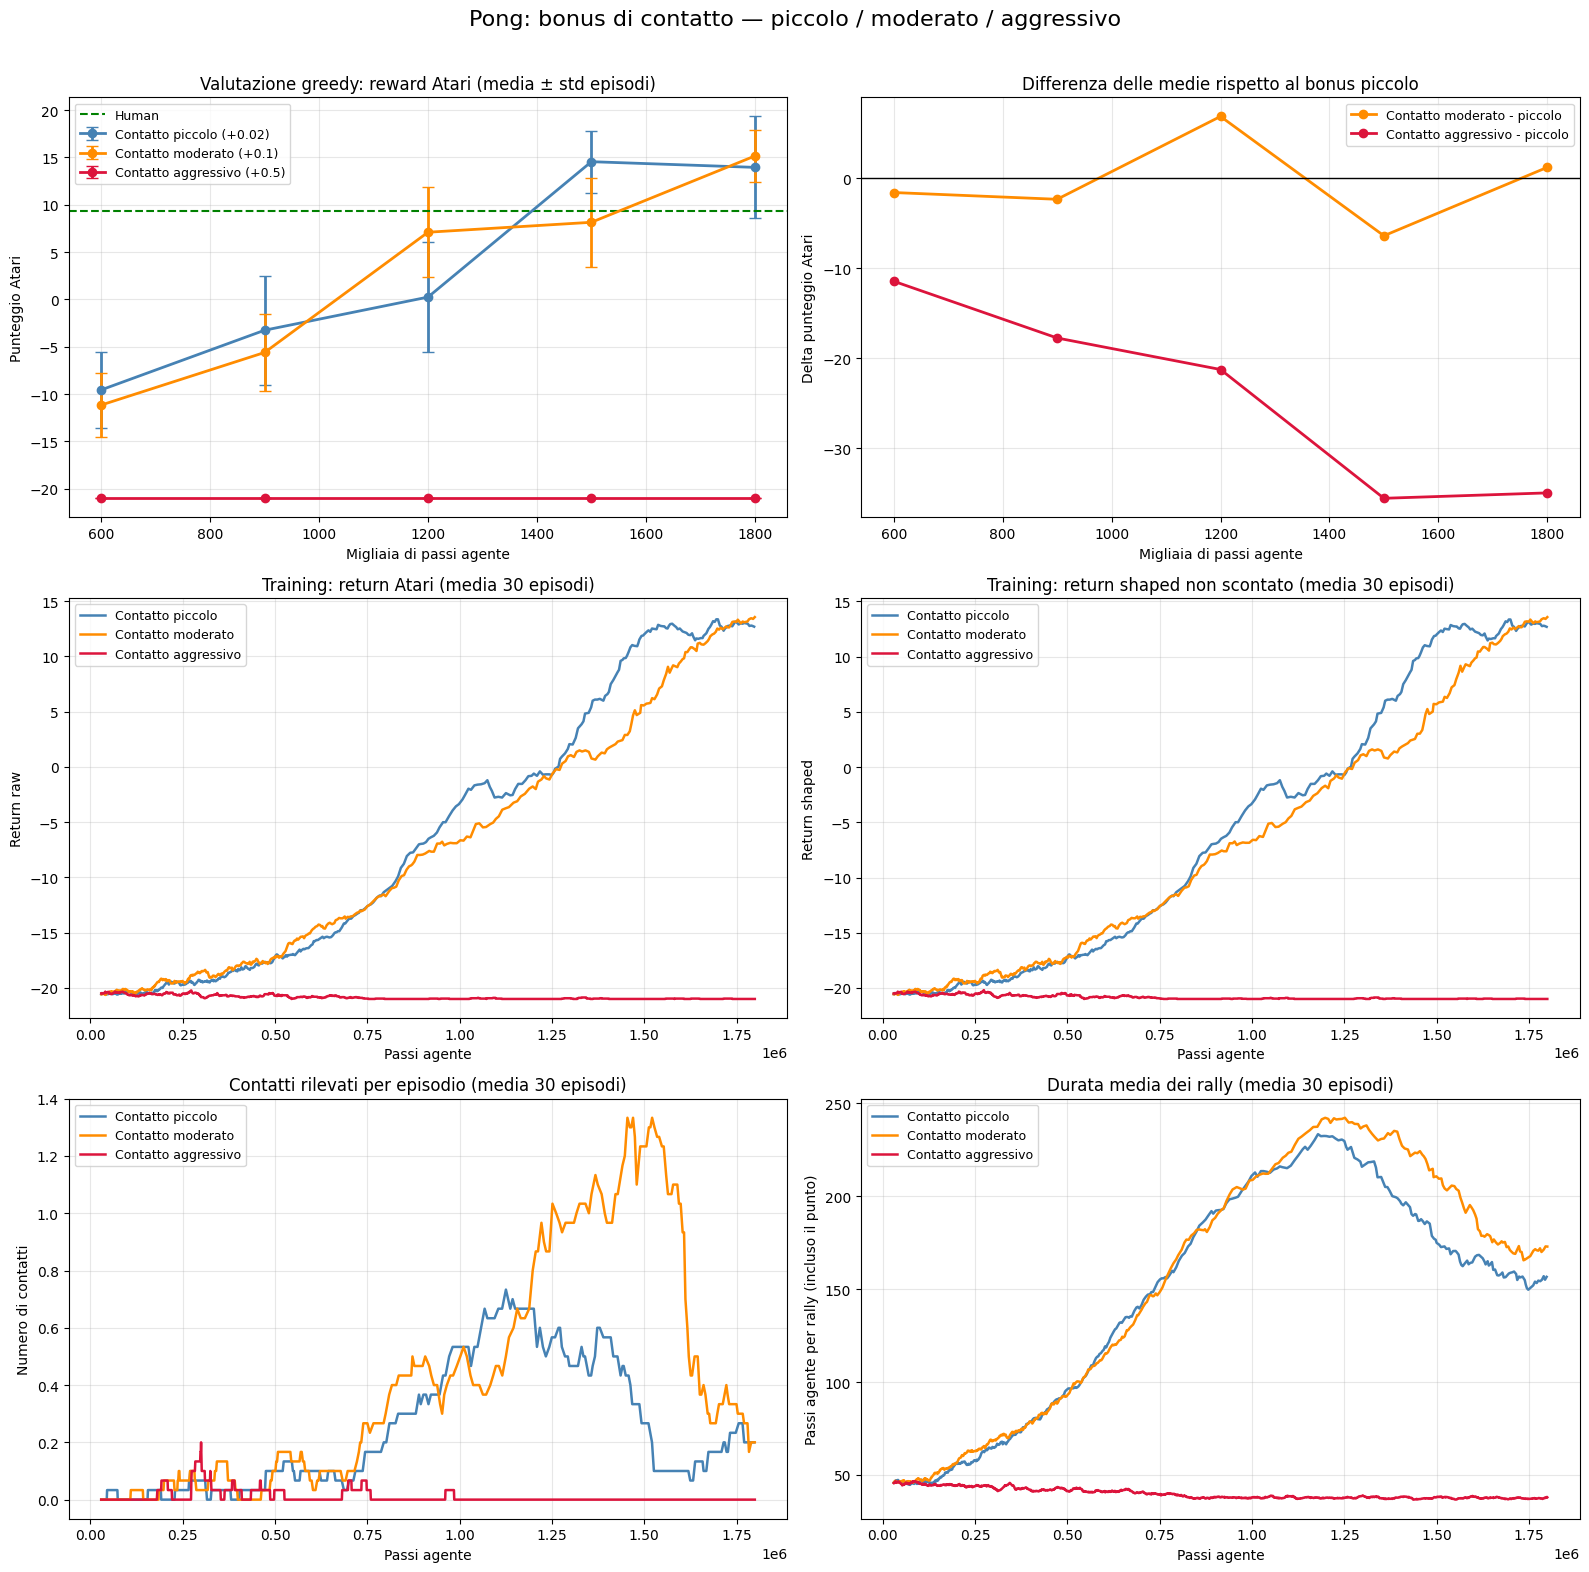

In [11]:
COLORS = {"small": "steelblue", "moderate": "darkorange", "aggressive": "crimson"}
RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]

def rolling_xy(run, key, window=30):
    values = np.asarray(run["history"][key], dtype=float)
    steps = np.asarray(run["history"]["step"], dtype=float)
    if len(values) < window:
        return np.array([]), np.array([])
    return steps[window-1:], np.convolve(values, np.ones(window)/window, mode="valid")

checkpoint_k = np.asarray(CHECKPOINTS) / 1000.0
small_scores = np.asarray([small_run["checkpoints"][s][0] for s in CHECKPOINTS])
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
ax_eval, ax_delta, ax_raw, ax_shaped, ax_diagnostic, ax_rally = axes.ravel()
for key, run in RUNS:
    color = COLORS[key]
    scores = np.asarray([run["checkpoints"][s][0] for s in CHECKPOINTS])
    std = np.asarray([run["checkpoints"][s][1] for s in CHECKPOINTS])
    legend_label = f"{run['label']} (+{run['contact_bonus']:g})"
    ax_eval.errorbar(checkpoint_k, scores, yerr=std, marker="o", capsize=4,
                     linewidth=2, color=color, label=legend_label)
    if key != "small":
        ax_delta.plot(checkpoint_k, scores-small_scores, marker="o", linewidth=2,
                      color=color, label=run["label"] + " - piccolo")
    for ax, metric in ((ax_raw, "raw_return"), (ax_shaped, "shaped_return"),
                       (ax_diagnostic, "contact_count"), (ax_rally, "mean_rally")):
        x, y = rolling_xy(run, metric)
        ax.plot(x, y, color=color, linewidth=1.8, label=run["label"])

ax_eval.axhline(HUMAN_BENCHMARK, color="green", linestyle="--", label="Human")
ax_eval.set(title="Valutazione greedy: reward Atari (media ± std episodi)",
            xlabel="Migliaia di passi agente", ylabel="Punteggio Atari")
ax_delta.axhline(0, color="black", linewidth=1)
ax_delta.set(title="Differenza delle medie rispetto al bonus piccolo",
             xlabel="Migliaia di passi agente", ylabel="Delta punteggio Atari")
ax_raw.set(title="Training: return Atari (media 30 episodi)", ylabel="Return raw")
ax_shaped.set(title="Training: return shaped non scontato (media 30 episodi)", ylabel="Return shaped")
ax_diagnostic.set(title="Contatti rilevati per episodio (media 30 episodi)", ylabel="Numero di contatti")
ax_rally.set(title="Durata media dei rally (media 30 episodi)", ylabel="Passi agente per rally (incluso il punto)")
for ax in (ax_raw, ax_shaped, ax_diagnostic, ax_rally):
    ax.set_xlabel("Passi agente")
for ax in axes.ravel():
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Pong: bonus di contatto — piccolo / moderato / aggressivo", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("confronto_reward_contatto_pong.png", dpi=160, bbox_inches="tight")
plt.show()